In [473]:
import torch
from src.utils import DoubleIntegrator2D, CustomLogger, solve_and_plot_ipopt
from src.sindy import CompiledFunctionLibrary, SINDyVectorized
from src.trainer import SparseTrainer, SparsePolicyBuilder2D
from src.data import get_policy_data
from src.plot import *

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [476]:
# Ground truth system model
gt_model = DoubleIntegrator2D()
# Sampling rate
ts = gt_model.params[1]["ts"]

# Problem dimensions
nx = gt_model.nx      # number of states
nu = gt_model.nu      # number of control inputs
nref = nx             # reference dimensions equal to state dimensions

# Constraint bounds
umin = -2.
umax = +2.
xmin = -5.
xmax = +5.


In [477]:
# build library once
lib = CompiledFunctionLibrary(
    n_features=nx, n_control=nu, is_policy=False,
    include_bias=True, max_degree=2,
    add_sqrt=False, add_xu=True, add_u_prod=True,
    add_fourier=False
)

# create model (multi-output)
sindy = SINDyVectorized(library=lib, n_out=nx, device=device)


In [478]:
sindy.pretty_print()

dx0/dt = +2.2616e-02·1 + -3.2087e-02·x0 + -4.4281e-02·x1 + +1.2324e-02·x2 + -2.8154e-02·x3 + +4.9619e-02·u0 + +3.9324e-02·u1 + +4.4821e-02·x0^2 + -4.3922e-02·x0*x1 + +4.0404e-02·x0*x2 + -4.8116e-02·x0*x3 + +9.8566e-03·x1^2 + -2.7158e-02·x1*x2 + +4.7433e-02·x1*x3 + +4.1393e-02·x2^2 + -3.1954e-02·x2*x3 + +2.2124e-03·x3^2 + -2.4266e-02·u0*u1 + +4.9582e-02·x0*u0 + -3.9296e-02·x0*u1 + +3.3126e-02·x1*u0 + +2.6838e-02·x1*u1 + -1.3788e-02·x2*u0 + +2.6331e-02·x2*u1 + -3.2397e-02·x3*u0 + +2.5047e-02·x3*u1
dx1/dt = +7.4214e-03·1 + +2.7148e-02·x0 + +3.5734e-02·x1 + +2.8745e-02·x2 + -4.5122e-02·x3 + -4.7165e-02·u0 + -2.8367e-02·u1 + +2.9744e-03·x0^2 + -8.3308e-03·x0*x1 + -4.3603e-02·x0*x2 + -5.1461e-03·x0*x3 + -5.4940e-03·x1^2 + -4.3660e-02·x1*x2 + +2.3454e-02·x1*x3 + -1.4691e-02·x2^2 + -3.6264e-02·x2*x3 + +2.3835e-02·x3^2 + -2.1357e-02·u0*u1 + -1.2498e-02·x0*u0 + +2.4566e-02·x0*u1 + +2.3127e-02·x1*u0 + -3.7766e-02·x1*u1 + -2.0270e-02·x2*u0 + +9.8498e-03·x2*u1 + -2.2614e-02·x3*u0 + +1.3837e-02·x3*u

In [479]:
from SparseDPC.data.getdata import get_data

nsim = 3000   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 3000     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

In [480]:
dyn_cfg = {
    # ---------- loss weights ----------
    "onestep_coef"   : 1.0,      # 1-step prediction error
    "ref_coef"       : 2.0,      # full-horizon (n-step) error
    "l1_coef"        : 3e-6,     # L¹ sparsity on SINDy coefficients
    "l1_decay"       : 0.3,

    # ---------- optimiser / schedule ----------
    "lr"             : 1e-3,     # AdamW learning-rate
    "epochs"         : 40000,   # gradient steps per coordinate model

    # ---------- pruning & early-stop ----------
    "threshold"      : 5e-2,     # initial coefficient cutoff
    "prune_every"    : 8000,    # epochs between pruning passes
    "threshold_mult" : 1.09,     # threshold ← threshold × multiplier
    "prune_noise"    : 0.05,     # std-dev of regrowth noise (0 ⇒ none)

    # ---------- training conveniences ----------
    "warmup"         : 300,      # epochs before enabling pruning
    "patience"       : 50,       # early-stop patience on dev_loss
}


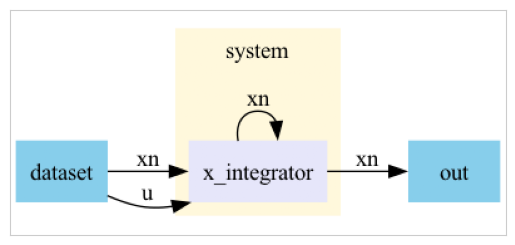

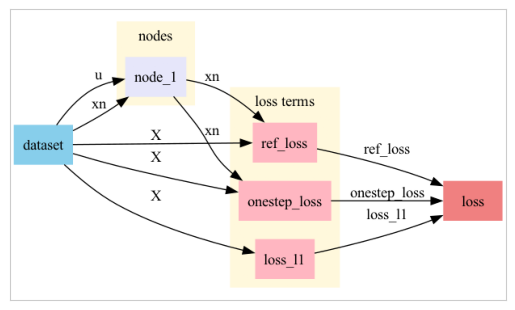

None


In [482]:
from neuromancer.loggers import BasicLogger
from neuromancer.system import Node, System
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.dynamics import ode, integrators


# One-element integrator for current state
integrator_x = integrators.Euler(sindy, h=ts)
integrator_node_x = Node(integrator_x, ['xn', 'u'], [f'xn'], name="x_integrator")
dynamics_model_x = System([integrator_node_x])
dynamics_model_x.show()

x = variable(f"X")
x_hat = variable(f'xn')[:, :-1, :]

# Define losses
onestep_loss_x = dyn_cfg["onestep_coef"] * ((x_hat[:, 1, :] == x[:, 1, :]) ^ 2)
onestep_loss_x.name = "onestep_loss"

reference_loss_x = dyn_cfg["ref_coef"] * ((x_hat == x) ^ 2)
reference_loss_x.name = "ref_loss"

# L1 sparsity regularization on model weights
l1_x = variable([x], lambda x: sum(torch.norm(p, p=1) for p in sindy.Xi))
loss_l1_x = dyn_cfg["l1_coef"] * (l1_x == 0)
loss_l1_x.name = "loss_l1"

# Assemble problem
objectives_x = [reference_loss_x, onestep_loss_x, loss_l1_x]
loss_x = PenaltyLoss(objectives_x, [])
problem_x = Problem([dynamics_model_x], loss_x)
problem_x.show()

lr = dyn_cfg["lr"]
optimizer_x = torch.optim.AdamW(problem_x.parameters(), lr=lr)

logger = CustomLogger(
    args=None,
    savedir='test',
    verbosity=200,
    stdout=['train_loss','dev_loss']
)




In [484]:

trainer_x = SparseTrainer(
    problem=problem_x,
    sindy=sindy,
    lr=lr,
    train_data=None,
    test_data=None,
    optimizers=optimizer_x,
    epochs=dyn_cfg["epochs"],
    train_metric='train_loss',
    eval_metric='dev_loss',
    logger=logger,
    device= device,
    threshold=dyn_cfg["threshold"],
    prune_every=dyn_cfg["prune_every"],
    warmup=300,
    patience=50,
    threshold_mult=dyn_cfg["threshold_mult"],
    prune_noise=dyn_cfg["prune_noise"],
    l1_decay=dyn_cfg["l1_decay"],
)

# Regenerate training data for updated horizon
trainer_x.train_data, trainer_x.dev_data = train_loader, dev_loader
trainer_x.problem = problem_x

# Train
best_model = trainer_x.train()
trainer_x.model.load_state_dict(best_model)


epoch: 0	train_loss: 2.044e+02	dev_loss: 1.288e+02	eltime:  0.15059
epoch: 200	train_loss: 3.787e-03	dev_loss: 5.440e-02	eltime:  16.72841
epoch: 400	train_loss: 1.897e-03	dev_loss: 3.428e-02	eltime:  31.28666
epoch: 600	train_loss: 1.085e-03	dev_loss: 2.081e-02	eltime:  45.87783
epoch: 800	train_loss: 6.281e-04	dev_loss: 1.344e-02	eltime:  60.46206
epoch: 1000	train_loss: 4.073e-04	dev_loss: 9.178e-03	eltime:  75.15640
epoch: 1200	train_loss: 2.737e-04	dev_loss: 6.505e-03	eltime:  89.71857
epoch: 1400	train_loss: 2.428e-04	dev_loss: 5.074e-03	eltime:  104.27383
epoch: 1600	train_loss: 1.303e-04	dev_loss: 3.452e-03	eltime:  118.84096
epoch: 1800	train_loss: 9.117e-05	dev_loss: 2.524e-03	eltime:  133.40780
epoch: 2000	train_loss: 1.092e-04	dev_loss: 1.895e-03	eltime:  148.11450
epoch: 2200	train_loss: 4.635e-05	dev_loss: 1.314e-03	eltime:  162.66850
epoch: 2400	train_loss: 3.437e-05	dev_loss: 9.386e-04	eltime:  177.28274
epoch: 2600	train_loss: 2.660e-05	dev_loss: 7.011e-04	eltime:  191

<All keys matched successfully>

In [485]:
sindy.pretty_print()

dx0/dt = +1.0000e+00·x1
dx1/dt = -1.9802e-01·x1 + +9.9004e-01·u0
dx2/dt = +1.0000e+00·x3
dx3/dt = -1.9800e-01·x3 + +9.9007e-01·u1


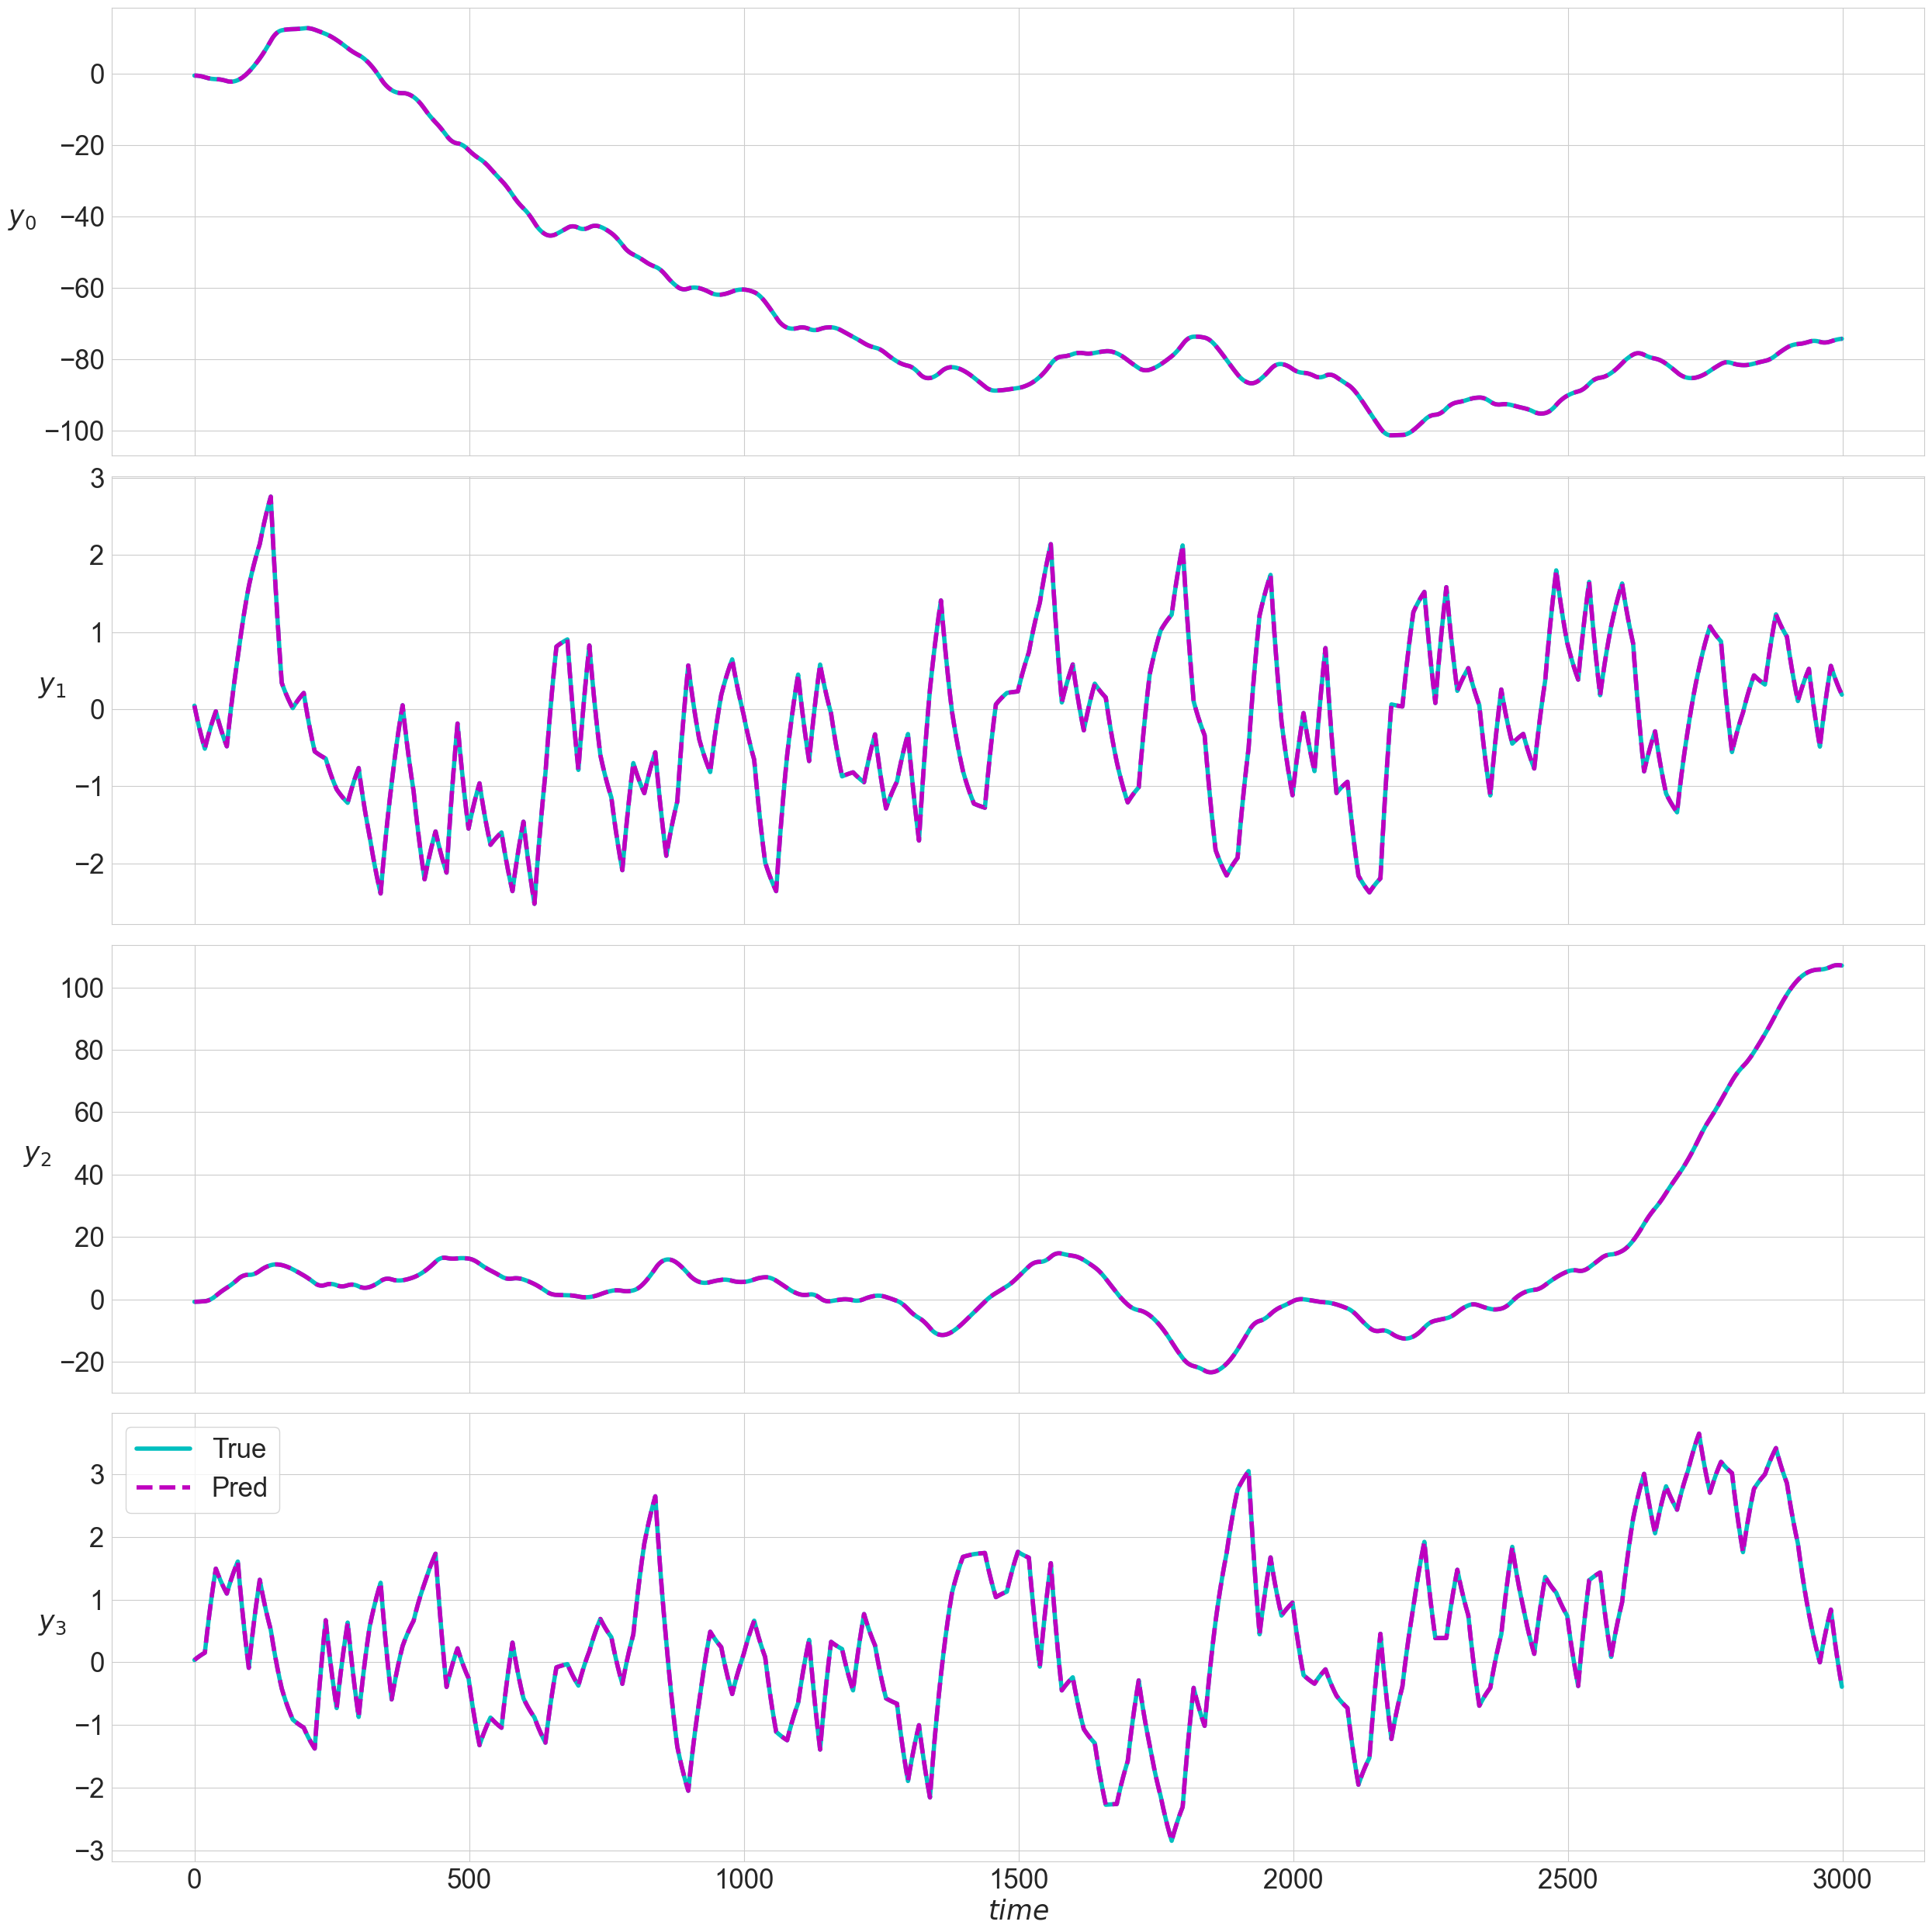

In [486]:
import matplotlib.pyplot as plt

# Create system for evaluation
sindy_system = System([integrator_node_x], nsteps=nsteps)
sindy_system.nsteps = test_data['X'].shape[1]

# Run simulation
test_output = sindy_system(test_data)

# Reshape for plotting
pred_traj = test_output['xn'][:, :-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().numpy().reshape(-1, nx).T

# Plot predicted vs. true trajectories
figsize = 25
fig, ax = plt.subplots(nx, figsize=(figsize, figsize))
labels = [f'$y_{k}$' for k in range(len(true_traj))]

for row, (t1, t2, label) in enumerate(zip(true_traj, pred_traj, labels)):
    axe = ax[row] if nx > 1 else ax
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1, 'c', linewidth=4.0, label='True')
    axe.plot(t2, 'm--', linewidth=4.0, label='Pred')
    axe.tick_params(labelbottom=False, labelsize=figsize)

axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)
axe.set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()


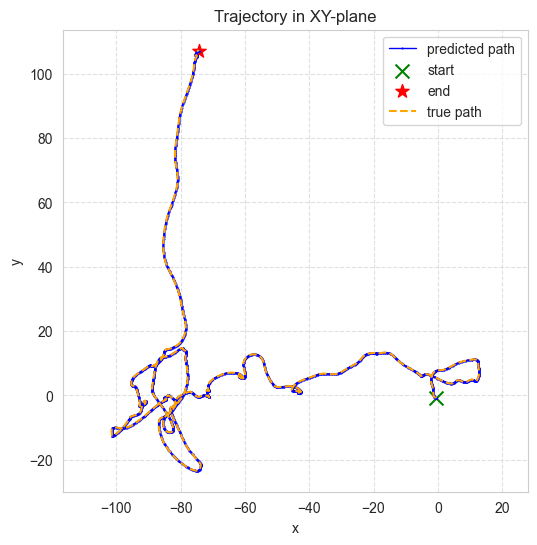

In [487]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
def plot_traj(pred_traj, true_traj=None, title="Trajectory in XY-plane"):
    """
    pred_traj: numpy array of shape (4, T)
               rows: [x, xdot, y, ydot]
    true_traj: numpy array of shape (4, T) (optional)
    """
    x_pred = pred_traj[0, :]
    y_pred = pred_traj[2, :]

    plt.figure(figsize=(6,6))
    # predicted
    plt.plot(x_pred, y_pred, marker="o", markersize=0.5, linewidth=1.0,
             label="predicted path", color="blue")
    plt.scatter(x_pred[0], y_pred[0], c="green", marker="x", s=100, label="start")
    plt.scatter(x_pred[-1], y_pred[-1], c="red", marker="*", s=100, label="end")

    # true path if given
    if true_traj is not None:
        x_true = true_traj[0, :]
        y_true = true_traj[2, :]
        plt.plot(x_true, y_true, linewidth=1.5, linestyle="--", color="orange", label="true path")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

# Example:
plot_traj(pred_traj, true_traj)


### Policy dataset with obstacle exclusion

- Builds train/dev `DataLoader`s for policy learning.
- Samples initial states (`xn`) and constant references (`r`) from rectangles.
- Rejects points inside ellipse:
  \( b(x-c)^2 + (y-d)^2 \ge (p/2)^2 \).

**Main steps**
- RNG split via `seed` (train/dev).
- `sample_xy_in_rect_outside`: uniform rect sampling with ellipse rejection.
- `_build_split`:
  - `xn`: positions + zero velocities.
  - `r`: constant ref over horizon.
  - Add obstacle params.

**Outputs**
- `train_loader`, `dev_loader` with dicts:
  - `"xn"` (B,1,nx), `"r"` (B,nsteps+1,2), `"obs_*"`.


In [776]:
ellipse_configs = {"p": 0.6,
                   "b": 1,
                   "c": 0.0,
                   "d": 0.0}

def make_square(center, length):
    """
    Build a rectangle ((x1,y1),(x2,y2)) from center and side length.
    center: (cx, cy)
    length: full side length
    """
    cx, cy = center
    half = length / 2.0
    return ((cx - half, cy - half), (cx + half, cy + half))

side = 0.5   # for example, 0.5 x 0.5 squares

# initial region center
init_center = (0.6, -0.6)
init_rect = make_square(init_center, side)

# reference region center)
ref_center = (-0.6, 0.6)
ref_rect = make_square(ref_center, side)

nsteps = 50
xmin = -1.
xmax = 1.
umin = -2.
umax = 2.

train_loader, dev_loader = get_policy_data(
    nsteps=nsteps, n_samples=3000, nx=nx, batch_size=200 ,device=device,
    ellipse_configs=ellipse_configs,
    init_rect=init_rect, ref_rect=ref_rect,
)


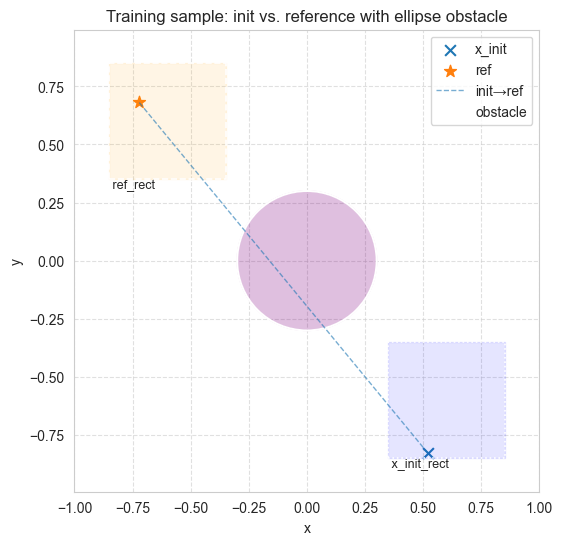

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Training sample: init vs. reference with ellipse obstacle'}, xlabel='x', ylabel='y'>)

In [778]:
# plotting a data sample from train loader
plot_training_sample_with_ellipse(
    train_loader,
    sample_idx=32,
    pos_idx=(0, 2),
    init_rect=init_rect,
    ref_rect=ref_rect,
    xmin=-1., xmax=1.
)

In [886]:
from src.utils import DoubleIntegrator2DParam

double_integrator = DoubleIntegrator2DParam()
double_integrator.mx = torch.nn.Parameter(torch.tensor(gt_model.mx), requires_grad=False)
double_integrator.my = torch.nn.Parameter(torch.tensor(gt_model.my), requires_grad=False)
double_integrator.cx = torch.nn.Parameter(torch.tensor(gt_model.cx), requires_grad=False)
double_integrator.cy = torch.nn.Parameter(torch.tensor(gt_model.cy), requires_grad=False)
double_integrator.kx = torch.nn.Parameter(torch.tensor(gt_model.kx), requires_grad=False)
double_integrator.ky = torch.nn.Parameter(torch.tensor(gt_model.ky), requires_grad=False)

pol_configs = {
    "l1_coef": 0.0002,
    "Q_con_obs": 100.0,
    "Q_con_x": 10.0,
    "Q_con_u": 10.0,
    "Q_u": 0.02,
    "Q_r": 1.0,
    "Q_dx": 0.0,
    "Q_du": 0.0001,
    "lr": 0.002,
    "epochs": 10000,
    "threshold": 0.08,
    "prune_every": 2000,
    "prune_every_min": 300,
    "prune_every_decay": 200,
    "change_prune_every": True,
    "threshold_mult": 1.3,
    "threshold_max" : 0.12,
    "prune_noise": 0.01,
    "lr_decay_gamma": 0.95,
    "lr_decay_step": 50,
    "l1_decay": 0.9,
}

refstep=1
policies_seed = 0


None


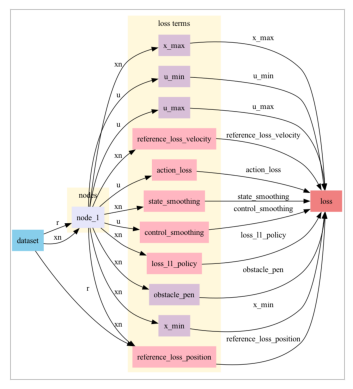

In [828]:
# build library once
policy_lib = CompiledFunctionLibrary(
    n_features=nx, n_control=nu, is_policy=True,
    include_bias=False, max_degree=2,
    add_sqrt=True, add_xu=True, add_u_prod=True,
    add_fourier=False
)

# create model (multi-output)
policy_sparse = SINDyVectorized(library=policy_lib, n_out=nu, policy_name=["u0","u1"], device=device, seed=policies_seed)

builder_SD_SINDy = SparsePolicyBuilder2D(
    dynamics_model= sindy,
    policy        = policy_sparse,
    is_sindy      = True,
    gt_model      = None,
    ts            = ts,
    nsteps        = nsteps,
    train_loader  = train_loader,
    dev_loader    = dev_loader,
    bounds        = dict(
                        xmin=xmin,
                        xmax=xmax,
                        umin=umin,
                        umax=umax
                    ),
    config        = pol_configs,
    obstacle_configs = ellipse_configs,
    refstep = refstep,
    seed          = policies_seed,
    device        = device,
    logger        = CustomLogger(args=None, savedir='runs', verbosity=50,
                                stdout=['dev_loss', 'train_loss'])
)

In [829]:
builder_SD_SINDy.policy.pretty_print()

u0 = -3.7434e-04·x0 + +2.6822e-02·x1 + -4.1152e-02·x2 + -3.6797e-02·x3 + -1.9258e-02·r0 + +1.3408e-02·r1 + -9.9066e-04·sqrt(x0) + +3.9644e-02·sqrt(x1) + -4.4372e-03·sqrt(x2) + +1.3231e-02·sqrt(x3) + -1.5111e-02·x0^2 + -9.8283e-03·x0*x1 + -4.7767e-02·x0*x2 + -3.3114e-02·x0*x3 + -2.0611e-02·x1^2 + +1.8522e-03·x1*x2 + +1.9767e-02·x1*x3 + +3.0001e-02·x2^2 + -3.3897e-02·x2*x3 + -2.1773e-02·x3^2 + +1.8161e-02·r0*r1 + +4.1519e-02·x0*r0 + -1.0290e-02·x0*r1 + +3.7416e-02·x1*r0 + -8.0592e-03·x1*r1 + +5.2907e-03·x2*r0 + +4.5274e-02·x2*r1 + -4.6384e-02·x3*r0 + -3.1477e-02·x3*r1
u1 = -1.2658e-02·x0 + -1.9490e-02·x1 + +4.3200e-02·x2 + -3.2409e-02·x3 + -2.3017e-02·r0 + -3.4932e-02·r1 + -4.6828e-02·sqrt(x0) + -2.9187e-02·sqrt(x1) + +4.2980e-02·sqrt(x2) + +2.2311e-02·sqrt(x3) + +2.4234e-02·x0^2 + +2.6296e-03·x0*x1 + -2.5634e-02·x0*x2 + +8.4592e-03·x0*x3 + -4.6685e-02·x1^2 + -3.6128e-02·x1*x2 + -2.5776e-02·x1*x3 + +3.1547e-02·x2^2 + +2.9316e-02·x2*x3 + -2.2175e-02·x3^2 + -1.8041e-03·r0*r1 + +3.1978e-02·

In [830]:
builder_SD_SINDy.train()

/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)
/opt/anaconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/constraint.py:172: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([200, 50, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(left, right)


epoch: 0	train_loss: 8.007e-01	dev_loss: 7.912e-01	eltime:  2.38678
epoch: 50	train_loss: 1.263e-02	dev_loss: 1.200e-02	eltime:  40.56729
epoch: 100	train_loss: 6.172e-03	dev_loss: 5.968e-03	eltime:  76.63828
epoch: 150	train_loss: 5.015e-03	dev_loss: 4.863e-03	eltime:  112.51316
epoch: 200	train_loss: 4.649e-03	dev_loss: 4.530e-03	eltime:  148.27175
epoch: 250	train_loss: 4.453e-03	dev_loss: 4.361e-03	eltime:  183.93463
epoch: 300	train_loss: 4.276e-03	dev_loss: 4.211e-03	eltime:  220.01421
epoch: 350	train_loss: 4.133e-03	dev_loss: 4.080e-03	eltime:  255.96010
epoch: 400	train_loss: 3.992e-03	dev_loss: 3.940e-03	eltime:  292.06302
epoch: 450	train_loss: 3.858e-03	dev_loss: 3.802e-03	eltime:  328.09298
epoch: 500	train_loss: 3.744e-03	dev_loss: 3.684e-03	eltime:  364.01932
epoch: 550	train_loss: 3.585e-03	dev_loss: 3.569e-03	eltime:  400.23174
epoch: 600	train_loss: 3.477e-03	dev_loss: 3.441e-03	eltime:  436.07431
epoch: 650	train_loss: 3.392e-03	dev_loss: 3.351e-03	eltime:  471.85039

In [892]:
policy_sparse.pretty_print()
print(policy_sparse.coef)

u0 = -5.4323e-01·x0 + +1.8101e-01·r1 + +3.5956e-01·sqrt(x0) + -2.2505e-01·sqrt(x3) + -6.6320e-01·x0*r1 + -1.4094e+00·x1*r1 + +1.3210e+00·x2*r0 + +1.1133e+00·x3*r0
u1 = +1.5959e-01·x1 + -6.5742e-01·x2 + -1.0599e+00·x3 + +6.5525e-01·r1 + +1.7086e-01·sqrt(x0)
tensor([[-0.5432,  0.0000],
        [ 0.0000,  0.1596],
        [ 0.0000, -0.6574],
        [ 0.0000, -1.0599],
        [ 0.0000,  0.0000],
        [ 0.1810,  0.6552],
        [ 0.3596,  0.1709],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [-0.2250,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [-0.6632,  0.0000],
        [ 0.0000,  0.0000],
        [-1.4094,  0.0000],
        [ 1.3210,  0.0000],
        [ 0.000

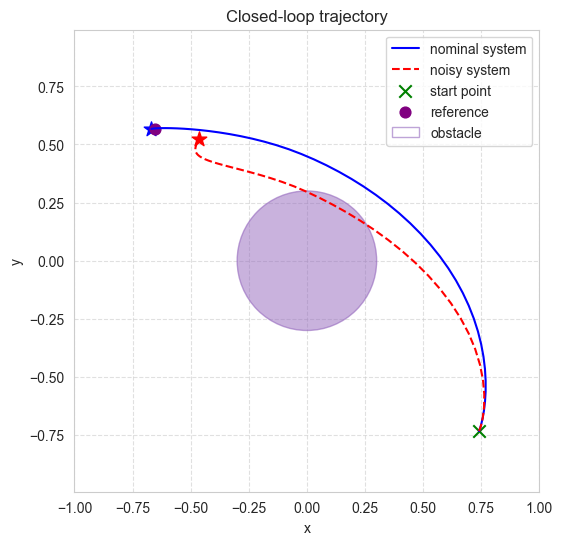

In [891]:
# Closed-loop simulation setup
import copy

nsteps_test = nsteps
data = make_test_sample(
    nx=nx, nsteps=nsteps_test, seed= 21
    , device=device,
    ellipse= ellipse_configs,
    init_vel_std=0.0,
    init_rect= init_rect,
    ref_rect= ref_rect,
)


double_integrator_noisy = DoubleIntegrator2DParam()
double_integrator_noisy.mx = torch.nn.Parameter(torch.tensor(gt_model.mx - 0.5), requires_grad=False)
double_integrator_noisy.cx = torch.nn.Parameter(torch.tensor(gt_model.cx - 0.1), requires_grad=False)
double_integrator_noisy.my = torch.nn.Parameter(torch.tensor(gt_model.my - 0.5), requires_grad=False)
double_integrator_noisy.cy = torch.nn.Parameter(torch.tensor(gt_model.cy - 0.1), requires_grad=False)


gt_integrator = integrators.Euler(double_integrator, h=torch.tensor(ts))
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

gt_integrator_noisy = integrators.Euler(double_integrator_noisy, h=torch.tensor(ts))
gt_integrator_node_noisy = Node(gt_integrator_noisy, ['xn', 'u'], ['xn'], name='model')


policy_node = Node(
            lambda xn,r : torch.clamp(builder_SD_SINDy.policy(xn, r), umin, umax),
            ['xn', 'r'], ['u'],
            name="policy_combined"
        )
# Compose symbolic closed-loop system: policy + true plant
gt_sindy_policy_system = copy.deepcopy(System([policy_node, gt_integrator_node]))
gt_sindy_policy_system_noisy = copy.deepcopy(System([policy_node, gt_integrator_node_noisy]))

# Simulate system
gt_sindy_policy_system.nsteps = nsteps_test
gt_sindy_policy_system_noisy.nsteps = nsteps_test

trajectories = gt_sindy_policy_system(data)
trajectories_noisy = gt_sindy_policy_system_noisy(data)

traj_x = trajectories["xn"]
traj_r = trajectories['r']

traj_x_noisy = trajectories_noisy["xn"]
traj_r_noisy = trajectories_noisy['r']

# suppose you produced a rollout: traj_x: (B, T, nx), traj_r: (B, T, 2)
fig, ax = plot_trajectories_with_ellipse(
    traj_list=[
        {"traj": traj_x, "label": "nominal system", "color": "blue"},
        {"traj": traj_x_noisy,   "label": "noisy system",   "color": "red", "linestyle": "--"}
    ],
    r = traj_r,
    p=ellipse_configs["p"], b=ellipse_configs["b"],
    c=ellipse_configs["c"], d=ellipse_configs["d"],
    batch_idx=0, xmin=xmin, xmax=xmax,
    title="Closed-loop trajectory"
)


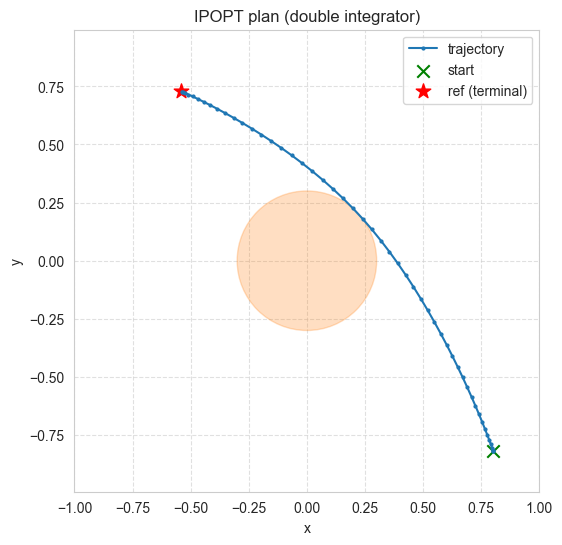

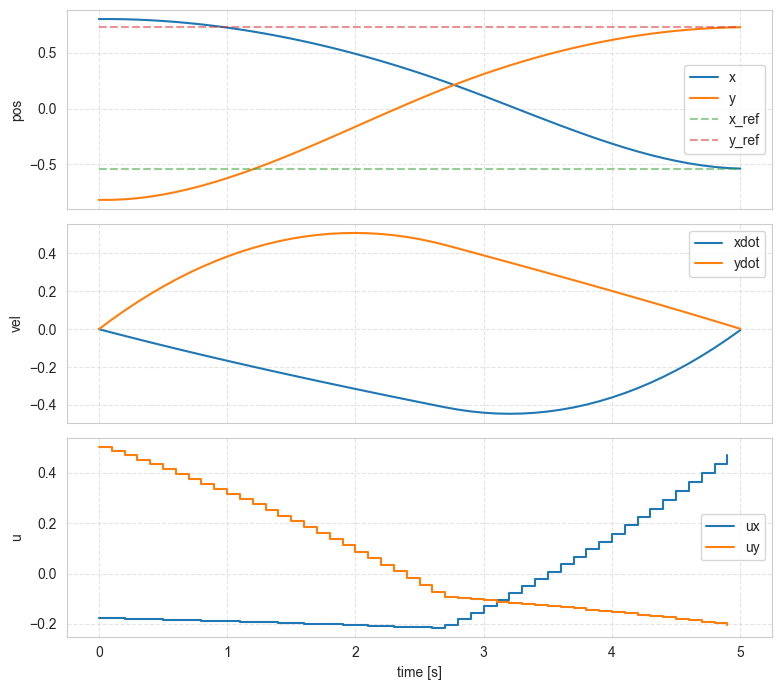

In [743]:

# -------------------- Example call --------------------
# your sample dict:
xmin = -1.
xmax = 1.
umin = -2.
umax = 2.
sample = make_test_sample(
    nx=4, nsteps=50, seed= 31, device=device,
    ellipse= ellipse_configs,
    init_vel_std=0.0,
    init_rect= init_rect,
    ref_rect= ref_rect,
)
scale = 1.
pol_configs = {
    "l1_coef": 0.008,
    "Q_con_obs": scale * 1e2,
    "Q_con_x": scale * 10.0,
    "Q_con_u": scale * 10.0,
    "Q_u": 0.001,
    "Q_r": 1.0,
    "Q_dx": scale * 0.0000,
    "Q_du": scale * 0.0001,
}
refstep=1

bounds = dict(xmin=xmin, xmax=xmax, umin=umin, umax=umax)

Xsol, Usol, J, fig_xy, fig_ts = solve_and_plot_ipopt(
    sample, pol_configs,
    ts=0.1,
    ellipse_cfg=ellipse_configs,
    bounds=bounds,
    use_msd=True,       # set True and pass m,k,c for MSD dynamics
    m=1.0, k=0.0, c=0.2,
    track_whole_horizon=False,
    refstep = refstep,
    add_state_smoothing=True,
    add_control_smoothing=True,
    title_xy="IPOPT plan (double integrator)"
)
plt.show()
